 # 1.04 — Do Central Park stations have different availability on weekends vs weekdays?

 **H0:** Stations around Central Park hold the same fill ratio on weekends and on weekdays.
 **H1:** The fill ratio differs between weekends and weekdays at those stations.

 The idea behind the hypothesis is that Central Park is a recreational destination.
 On weekdays the stations around it serve commuters; on weekends they serve people
 going to the park for leisure. If those two crowds behave differently, the bikes
 sitting at the dock should look different on a Saturday than on a Tuesday.

 The metric is `fill_ratio` (num_bikes_available / capacity), a capacity-normalized
 level that compares fairly across docks of different sizes. The two groups are
 weekend station-hours and weekday station-hours, so this is a TWO-sample test
 (different days, not the same dock measured twice). I use Welch's t-test because
 the two groups differ in size and variance.

 This is the one hypothesis test that uses 2019, 2021, AND 2026 rather than 2026
 alone. The Central Park subset is small (about a hundred stations), so I need all
 three years to get stable group means. The test has nothing to do with e-bikes, so
 the usual reason for sticking to 2026 (e-bike counts are zero-filled before 2026)
 does not apply here.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from citibike.config import DB_CONFIG  # noqa: E402

pd.set_option("display.max_columns", 20)

FIGURES_DIR = Path("../reports/figures")

 ## Define the Central Park stations and pull their fill ratios

 Two things make this pull trickier than the earlier notebooks.

 First, which stations count as "Central Park" stations. There is no flag for this,
 so I draw a box around the park and its perimeter avenues: roughly 59th Street up to
 110th Street, and Central Park West across to 5th Avenue, with a short buffer so a
 dock just off the corner still counts. Any station whose coordinates fall in that
 box is a Central Park station. No bikes live inside the park itself, so in practice
 this captures the ring of docks around the edges, which is exactly the recreational
 zone the hypothesis is about.

 Second, the station ID namespaces do not match across years. The 2019 and 2021 rows
 use the old integer station IDs, while the 2026 rows use the modern UUIDs. So I build
 the Central Park station list from two coordinate sources and union them: the modern
 `station_information` table covers the 2026 UUIDs, and `station_id_crosswalk` covers
 the legacy integer IDs. A row in training_features matches if its station_id appears
 in either list.

 On the weekend flag: the timestamp is stored in UTC, and a NYC weekend does not line
 up with a UTC weekend at the edges (Friday 9pm in New York is already Saturday in UTC).
 To avoid mislabeling those late-evening hours I convert the timestamp to New York local
 time first, then read the day of week off that. Sunday and Saturday are the weekend.

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)

with conn.cursor() as cur:
    cur.execute("SET max_parallel_workers_per_gather = 0;")

sql = """
    WITH cp_stations AS (
        SELECT station_id AS sid
        FROM station_information
        WHERE lat BETWEEN 40.762 AND 40.803
          AND lon BETWEEN -73.984 AND -73.947
        UNION
        SELECT legacy_id AS sid
        FROM station_id_crosswalk
        WHERE lat BETWEEN 40.762 AND 40.803
          AND lon BETWEEN -73.984 AND -73.947
    )
    SELECT
        EXTRACT(YEAR FROM tf."timestamp")::int AS year,
        CASE
            WHEN EXTRACT(DOW FROM (tf."timestamp" AT TIME ZONE 'America/New_York')) IN (0, 6)
            THEN 'weekend' ELSE 'weekday'
        END AS day_type,
        tf.fill_ratio
    FROM training_features tf
    JOIN cp_stations c ON c.sid = tf.station_id
    WHERE EXTRACT(YEAR FROM tf."timestamp") IN (2019, 2021, 2026)
      AND tf.horizon_minutes = 60
      AND tf.fill_ratio IS NOT NULL;
"""
df = pd.read_sql(sql, conn)
conn.close()
print(f"Rows loaded: {len(df):,}")
df.head()

<ipython-input-2-2e358781c1c9>:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Rows loaded: 1,570,318


,year,day_type,fill_ratio
0,2026,weekday,0.081081
1,2026,weekday,0.000000
2,2026,weekday,0.000000
3,2026,weekday,0.027027
4,2026,weekday,0.054054


 ## Split into the two groups

 weekend = Saturday and Sunday station-hours (NYC local), weekday = Monday through
 Friday. These are independent observations, so everything from here compares the
 two arrays directly.

In [ ]:
weekend = df.loc[df["day_type"] == "weekend", "fill_ratio"]
weekday = df.loc[df["day_type"] == "weekday", "fill_ratio"]

n_weekend = len(weekend)
n_weekday = len(weekday)
print(f"Weekend station-hours: n = {n_weekend:,}")
print(f"Weekday station-hours: n = {n_weekday:,}")

Weekend station-hours: n = 441,875
Weekday station-hours: n = 1,128,443


 ## Descriptive stats

 Before any test I check the raw means and spreads. If the weekend crowd really does
 change how full these docks sit, the two means should separate. A higher weekend mean
 would say docks stay fuller on weekends (less commuter drain); a lower one would say
 the park pulls bikes out faster than commuters do.

In [ ]:
desc = pd.DataFrame({
    "weekend": weekend.describe(percentiles=[0.25, 0.5, 0.75]),
    "weekday": weekday.describe(percentiles=[0.25, 0.5, 0.75]),
}).loc[["count", "mean", "std", "25%", "50%", "75%"]]
print(desc.round(4))

           weekend       weekday
count  441875.0000  1.128443e+06
mean        0.2860  2.823000e-01
std         0.2621  2.696000e-01
25%         0.0750  5.560000e-02
50%         0.1961  1.935000e-01
75%         0.4474  4.516000e-01


 ## Look at each year on its own first

 Before I pool all three years together I want to see them separately, because the
 three years come from very different eras of the network and the fill ratios are not
 on the same baseline (2026 docks sit much fuller than 2019 ones). If I only looked at
 the pooled number I might miss that the years disagree with each other. This is the
 most informative table in the notebook.

In [ ]:
by_year = (
    df.groupby(["year", "day_type"])["fill_ratio"]
    .agg(["count", "mean"])
    .round(4)
    .unstack("day_type")
)
by_year["weekend_minus_weekday"] = (
    by_year[("mean", "weekend")] - by_year[("mean", "weekday")]
).round(4)
print(by_year)

           count            mean         weekend_minus_weekday
day_type weekday weekend weekday weekend                      
year                                                          
2019      579542  225184  0.2823  0.2927                0.0104
2021      469892  184203  0.2549  0.2436               -0.0113
2026       79009   32488  0.4448  0.4798                0.0350


 ## What is driving the differences across years?

 2019 and 2026 both show weekends running fuller than weekdays, but 2021 flips the
 other way. Here is my read on why each year looks the way it does.

 **2019 -- weekends 1.0pp fuller than weekdays.** This is the normal pre-COVID pattern.
 Commuters drain stations hard Monday through Friday during rush hour. On weekends that
 commuter pressure disappears, so the docks sit a bit fuller even with park visitors
 using them. The recreational crowd is less intense than rush-hour commuters.

 **2021 -- weekends 1.1pp emptier than weekdays.** This is the COVID recovery year and
 almost certainly an artifact of that unusual period rather than a real behavioral shift.
 Two things probably combined to flip the direction. First, a lot of people were still
 working from home, so the usual weekday commuter drain was much weaker than normal.
 Second, outdoor recreation surged in 2021 -- people were avoiding indoor venues and
 spending a lot more time in parks. Weekend riding around Central Park was probably
 unusually intense compared to the quiet weekday baseline, which is the opposite of the
 normal pattern.

 **2026 -- weekends 3.5pp fuller than weekdays.** The largest gap of the three years.
 NYC commuting is back to normal, so weekday drain is strong again. The gap is also
 wider than 2019, which I think is partly explained by e-bikes. As notebook 1.01 showed,
 e-bikes get checked out about 3.6x faster than classic bikes. The e-bike fleet has grown
 a lot since 2019, so weekday rush-hour drain hits harder now than it did then, which
 makes the weekend contrast bigger.

 The bottom line: 2021 is the odd one out, and the most likely reason is COVID. The 2019
 and 2026 results agree on direction, and 2026 is the cleanest and most relevant read for
 how the system behaves today.

 ## Two-sample Welch t-test on the pooled data

 The headline test pools all three years, since that is what the hypothesis asks at
 the station level. Welch's t-test (equal_var=False) handles the unequal group sizes
 and variances without assuming a shared variance.

 H0: mean(weekend) - mean(weekday) = 0

In [ ]:
t_stat, p_value = stats.ttest_ind(weekend, weekday, equal_var=False)
mean_weekend = weekend.mean()
mean_weekday = weekday.mean()
mean_diff = mean_weekend - mean_weekday

print(f"Mean fill ratio weekend: {mean_weekend:.4f}")
print(f"Mean fill ratio weekday: {mean_weekday:.4f}")
print(f"Mean difference (weekend - weekday): {mean_diff:+.4f}")
print(f"t = {t_stat:.4f}   p = {p_value:.4e}")

Mean fill ratio weekend: 0.2860
Mean fill ratio weekday: 0.2823
Mean difference (weekend - weekday): +0.0037
t = 7.8792   p = 3.3001e-15


 ## Effect size and 95% CI

 At this many rows the p-value is effectively zero no matter what, so Cohen's d and
 the confidence interval are the numbers that matter. Cohen's d uses the pooled
 standard deviation; the CI on the difference uses the Welch standard error.

In [ ]:
s_weekend, s_weekday = weekend.std(ddof=1), weekday.std(ddof=1)

pooled_sd = np.sqrt(
    ((n_weekend - 1) * s_weekend**2 + (n_weekday - 1) * s_weekday**2)
    / (n_weekend + n_weekday - 2)
)
cohens_d = mean_diff / pooled_sd

se_diff = np.sqrt(s_weekend**2 / n_weekend + s_weekday**2 / n_weekday)
ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f"Mean difference (weekend - weekday): {mean_diff:+.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Cohen's d: {cohens_d:.4f}")

se_weekend = s_weekend / np.sqrt(n_weekend)
se_weekday = s_weekday / np.sqrt(n_weekday)
weekend_ci = (mean_weekend - 1.96 * se_weekend, mean_weekend + 1.96 * se_weekend)
weekday_ci = (mean_weekday - 1.96 * se_weekday, mean_weekday + 1.96 * se_weekday)

Mean difference (weekend - weekday): +0.0037
95% CI: [0.0028, 0.0046]
Cohen's d: 0.0138


 ## Bar chart — the pooled picture

 Two bars, one for weekends and one for weekdays, showing the average fill ratio. The
 little whiskers show how sure I am of each average. The two bars land almost on top
 of each other, which is the whole point: across all three years combined, weekends
 and weekdays look nearly the same at these stations.

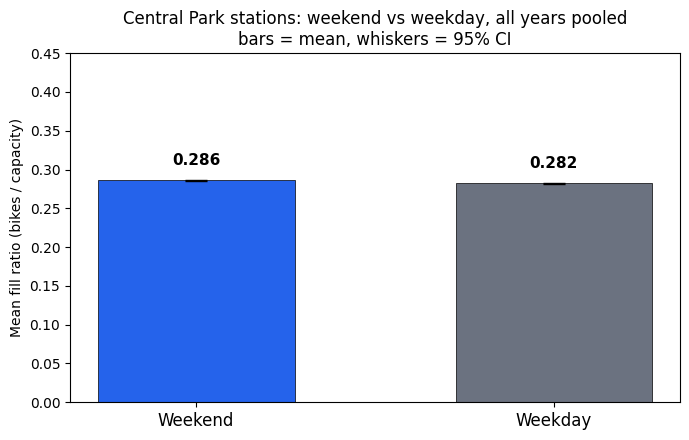

Saved -> reports/figures/1.04_bar_chart.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

errors = [1.96 * s_weekend / np.sqrt(n_weekend), 1.96 * s_weekday / np.sqrt(n_weekday)]

ax.bar([0, 1], [mean_weekend, mean_weekday], yerr=errors, capsize=8,
       color=["#2563EB", "#6B7280"], width=0.55, edgecolor="black", linewidth=0.5)

for x, m in zip([0, 1], [mean_weekend, mean_weekday]):
    ax.text(x, m + 0.02, f"{m:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Weekend", "Weekday"], fontsize=12)
ax.set_ylabel("Mean fill ratio (bikes / capacity)", fontsize=10)
ax.set_ylim(0, 0.45)
ax.set_title(
    "Central Park stations: weekend vs weekday, all years pooled\nbars = mean, whiskers = 95% CI",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.04_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.04_bar_chart.png")

 ## Bar chart — why the pooled picture hides the real story

 The pooled chart says "no difference," but that is misleading. When I split by year,
 two of the three years show weekends running fuller than weekdays, and one year (2021)
 runs the other way. Averaging them together cancels the effect out to almost nothing.
 This second chart puts the three years side by side so you can see the disagreement.
 A blue bar taller than its grey partner means that year had fuller docks on weekends.

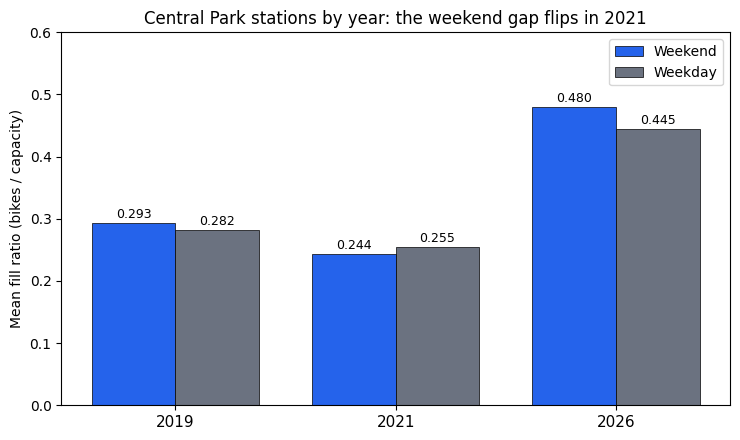

Saved -> reports/figures/1.04_bar_chart_by_year.png


In [ ]:
years = sorted(df["year"].unique())
wknd_means = [df[(df["year"] == y) & (df["day_type"] == "weekend")]["fill_ratio"].mean() for y in years]
wkdy_means = [df[(df["year"] == y) & (df["day_type"] == "weekday")]["fill_ratio"].mean() for y in years]

x = np.arange(len(years))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x - bar_w / 2, wknd_means, bar_w, label="Weekend", color="#2563EB", edgecolor="black", linewidth=0.5)
ax.bar(x + bar_w / 2, wkdy_means, bar_w, label="Weekday", color="#6B7280", edgecolor="black", linewidth=0.5)

for xi, m in zip(x - bar_w / 2, wknd_means):
    ax.text(xi, m + 0.008, f"{m:.3f}", ha="center", fontsize=9)
for xi, m in zip(x + bar_w / 2, wkdy_means):
    ax.text(xi, m + 0.008, f"{m:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], fontsize=11)
ax.set_ylabel("Mean fill ratio (bikes / capacity)", fontsize=10)
ax.set_ylim(0, 0.6)
ax.legend(fontsize=10)
ax.set_title("Central Park stations by year: the weekend gap flips in 2021", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.04_bar_chart_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.04_bar_chart_by_year.png")

 ## Retrospective power analysis

 I want to confirm the pooled test was not underpowered, even though the effect turned
 out to be tiny. TTestIndPower with the actual Cohen's d and the group-size ratio
 returns the minimum number of weekend rows needed to detect that effect at 80% power.

In [ ]:
power_analysis = TTestIndPower()
ratio = n_weekday / n_weekend
n_required = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    alpha=0.05,
    power=0.80,
    ratio=ratio,
    alternative="two-sided",
)
print(f"Min weekend rows needed (80% power, a=0.05): {n_required:,.0f}")
print(f"Actual weekend rows:                          {n_weekend:,}")
print(f"Overpowered by:                               {n_weekend / n_required:,.1f}x")

Min weekend rows needed (80% power, a=0.05): 57,255
Actual weekend rows:                          441,875
Overpowered by:                               7.7x


 ## Conclusion

 Technically I reject H0: pooled across 2019, 2021, and 2026, Central Park stations sat
 at a mean fill ratio of 0.286 on weekends versus 0.282 on weekdays, a difference of
 +0.0037 (95% CI: 0.0028 to 0.0046, Cohen's d = 0.014, p < 0.0001). The confidence
 interval excludes zero, so the difference is real in the statistical sense.

 But the honest answer is that this pooled difference is meaningless on its own. Cohen's
 d of 0.014 is a negligible effect, far below the 0.2 that even counts as "small," and a
 0.37 percentage point gap in fill ratio is not something a rider would ever notice. More
 importantly, the pooled number hides a disagreement between the years. In 2019 and 2026
 weekends ran fuller than weekdays (by about 1.0 and 3.5 percentage points), while in 2021
 weekends ran emptier (by about 1.1 points). Averaging three years that do not agree on the
 direction produces a near-zero result that does not describe any single year well.

 The most recent and most relevant year, 2026, is the cleanest read: weekend fill ratio
 0.480 versus weekday 0.445, weekends about 3.5 points fuller. That direction fits the
 recreational story. On weekdays commuters drain these stations; on weekends there is no
 commuter rush, so the docks sit fuller even with park visitors using them. The 2021
 reversal is most likely an artifact of that era of the network rather than a real
 behavioral flip, but I cannot prove that from this data alone.

 **Limitations:** the three years are not on the same fill-ratio baseline, so pooling them
 is a blunt instrument and the per-year split is the better view. 2026 covers only May and
 June, so there is no winter recreational pattern in it. The Central Park station set is
 defined by a coordinate box, which is a reasonable but hard cutoff. A natural follow-up is
 to run the test on 2026 alone once more months of live data accumulate, which would give a
 single clean era with enough rows to stand on its own.